# Modelos de Transfer Learning

Este notebook implementa **tres arquitecturas preentrenadas** de *transfer learning* para la clasificación de imágenes del juego **"Piedra, Papel o Tijera"**, utilizando los modelos **MobileNetV2**, **ResNet50V2** e **InceptionV3**, todos preentrenados con los pesos de **ImageNet**.

El objetivo es comparar el desempeño de modelos con diferente complejidad (ligero, mediano y pesado) y analizar cómo el tamaño y la profundidad de cada red afectan la capacidad de generalización sobre un conjunto reducido de datos.


### Principales actividades:

- Carga de los datos preprocesados (`X_hand.npy`, `y_hand.npy`) y su división en entrenamiento y validación.  
- Normalización de las imágenes y codificación *one-hot* de las etiquetas.  
- Implementación de **aumento de datos (data augmentation)** mediante `ImageDataGenerator` con transformaciones como:
  - Rotación
  - Desplazamiento horizontal y vertical
  - Zoom
  - Flip horizontal
- Integración de tres modelos de *transfer learning* con pesos preentrenados de *ImageNet*:  
  - **MobileNetV2** → modelo ligero (bajo número de parámetros y alta eficiencia).  
  - **ResNet50V2** → modelo de complejidad media (buena precisión y estabilidad).  
  - **InceptionV3** → modelo profundo (alta capacidad de representación, pero mayor costo computacional).  
- Adición de un **clasificador superior personalizado** que incluye:
  - Capa `GlobalAveragePooling2D`  
  - Capa `Dense(256, relu)`  
  - Capa `Dropout(0.4)`  
  - Capa de salida `Dense(num_classes, softmax)`  
- Entrenamiento y evaluación individual de cada modelo.  
- Comparación de resultados de precisión, pérdida y matrices de confusión.  
- Guardado de los modelos entrenados:
  - `modelo_transfer_MobileNetV2.keras`
  - `modelo_transfer_ResNet50V2.keras`
  - `modelo_transfer_InceptionV3.keras`

---

> El uso de *transfer learning* permite aprovechar representaciones visuales aprendidas a partir de millones de imágenes, acelerando el entrenamiento y mejorando el rendimiento en tareas con conjuntos de datos pequeños.  
> Cada modelo ofrece un compromiso diferente entre velocidad, consumo de memoria y precisión, lo que permite explorar estrategias de despliegue desde dispositivos embebidos (como Raspberry Pi) hasta entornos de cómputo de alto rendimiento.

---
             ┌──────────────────────────────────────┐
             │        Modelo Preentrenado           │
             │        (por ej. InceptionV3)         │
             │     Entrenado con el dataset          │
             │             ImageNet                  │
             └───────────────┬───────────────────────┘
                             │
                             ▼
                ┌──────────────────────────┐
                │  Extracción de características  │
                │  (capas convolucionales)        │
                │   ↓ Aprenden bordes, texturas,  │
                │     formas y patrones visuales  │
                └──────────────────────────┘
                             │
                             ▼
             ┌──────────────────────────────────────┐
             │      Capas Superiores Personalizadas  │
             │  (añadidas por el usuario)            │
             │  - GlobalAveragePooling2D()           │
             │  - Dense(256, activation='relu')      │
             │  - Dropout(0.4)                       │
             │  - Dense(num_classes, softmax)        │
             └──────────────────────────────────────┘
                             │
                             ▼
             ┌──────────────────────────────────────┐
             │     Entrenamiento en el nuevo dataset │
             │     ("Piedra, Papel o Tijera")        │
             │   Solo se ajustan los pesos de las    │
             │   capas superiores (el extractor      │
             │   permanece congelado)                │
             └──────────────────────────────────────┘
                             │
                             ▼
             ┌──────────────────────────────────────┐
             │     Evaluación y Guardado del Modelo │
             │  - Precisión y pérdida por época     │
             │  - Matriz de confusión               │
             │  - Guardado:                         │
             │    modelo_transfer_X.keras           │
             └──────────────────────────────────────┘



![Imagen](https://docs.google.com/uc?export=download&id=1YOPZNVMxccA89SVO8NAJewx73rutAwhQ)


In [ ]:
from google.colab import drive
drive.mount('/content/MyDrive')

In [ ]:
import os
os.chdir('DIRECTORIO DE TRABAJO')

In [1]:
!ls dataset

ls: cannot access 'dataset': No such file or directory


In [2]:
from numpy import load

X = load('X_hand.npy')
y = load('y_hand.npy')

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
X_train.shape

(1206, 64, 64, 3)

In [4]:

X_train_scaled  = X_train / 255
X_test_scaled  = X_test / 255

In [5]:
# one hot encode outputs
from tensorflow.keras.utils import to_categorical

y_train = to_categorical( y_train )
y_test = to_categorical( y_test )

In [6]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
#from keras.layers.convolutional import Conv2D
#from keras.layers.convolutional import MaxPooling2D
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import tensorflow as tf

# --- Función personalizada para añadir oscuridad y ruido ---
def dark_and_noise(image):
    # Oscurecer la imagen (factor entre 0.5 y 0.9)
    factor = np.random.uniform(0.01, 0.35)
    image = image * factor
    image = np.clip(image, 0, 1)

    # Agregar ruido gaussiano
    noise = np.random.normal(0, 0.05, image.shape)  # media 0, desviación 0.05
    image = image + noise
    image = np.clip(image, 0, 1)

    return image

# --- Aumento de datos SOLO para entrenamiento ---
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    #brightness_range=[0.8, 1.2],   # incluye imágenes más oscuras y más claras
    #preprocessing_function=dark_and_noise  # aplica oscuridad + ruido
)

# --- Generador sin aumento (solo normalización) para validación ---
test_datagen = ImageDataGenerator()

# --- Generadores desde arrays numpy ---
train_generator = train_datagen.flow(X_train_scaled, y_train, batch_size=32)
val_generator = test_datagen.flow(X_test_scaled, y_test, batch_size=32)


#https://machinelearningmastery.com/how-to-configure-image-data-augmentation-when-training-deep-learning-neural-networks/
#https://faroit.com/keras-docs/1.2.2/preprocessing/image/
#https://towardsdatascience.com/exploring-image-data-augmentation-with-keras-and-tensorflow-a8162d89b844

Modelo

1. Conv 16 (3,3) , relu
2. MP (2,2)
3. Conv 32 (3,3) , relu  
4. MP (2,2)
5. Flatten
6. 128 , relu
7. num_classes, softmax

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
num_classes=3



In [9]:
# ============================================
# MODELO DE TRANSFER LEARNING (LIGERO)
# ============================================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input

In [10]:
# Definir número de clases (ajusta según tu dataset)
num_classes = 3


In [11]:
# Cargar MobileNetV2 preentrenado en ImageNet, sin la parte densa final (top)
base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

/tmp/ipykernel_22903/2533726482.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
# Congelar todas las capas de la base
base_mobilenet.trainable = False

# Construcción del modelo final
x = base_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model_mobilenet = Model(inputs=base_mobilenet.input, outputs=output)

In [14]:

# Compilación
model_mobilenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [15]:
# Entrenamiento
history_mobilenet = model_mobilenet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25
)


Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 792ms/step - accuracy: 0.5738 - loss: 0.9345 - val_accuracy: 0.6725 - val_loss: 0.7312
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.6766 - loss: 0.7267 - val_accuracy: 0.6998 - val_loss: 0.6814
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7164 - loss: 0.6604 - val_accuracy: 0.7022 - val_loss: 0.6467
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.7347 - loss: 0.6223 - val_accuracy: 0.7221 - val_loss: 0.6563
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7421 - loss: 0.5897 - val_accuracy: 0.7196 - val_loss: 0.6157
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7786 - loss: 0.5459 - val_accuracy: 0.7419 - val_loss: 0.6246
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7844 - loss: 0.5394 - val_accuracy: 0.7568 - val_loss: 0.5883
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8002 - loss: 0.5169 - val_accuracy: 0.7568 -

In [16]:

# Evaluación final
scores = model_mobilenet.evaluate(X_test_scaled, y_test, verbose=0)
print('Error del modelo MobileNetV2 : %.2f%%' % (100 - scores[1] * 100))

# Guardado del modelo
model_mobilenet.save('modelo_transfer_MobileNetV2.keras')

Error del modelo MobileNetV2 : 23.57%


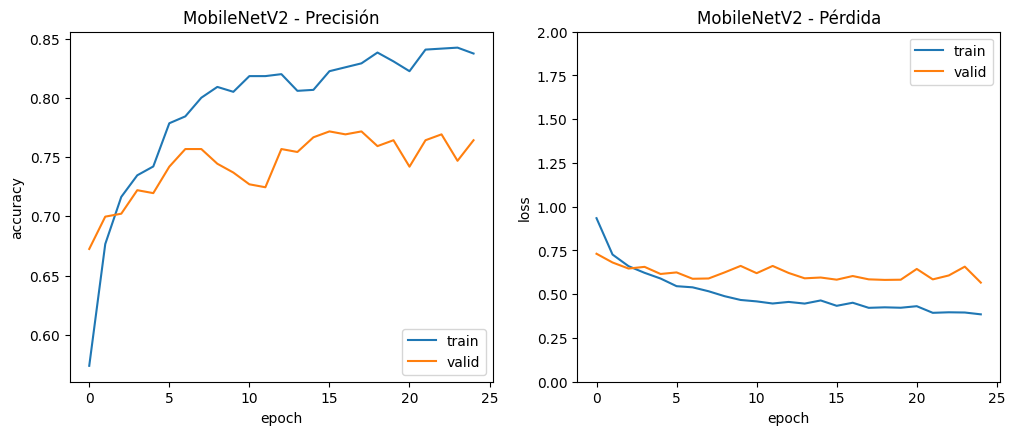

In [17]:

# Visualización del desempeño
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.title('MobileNetV2 - Precisión')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='lower right')
plt.subplot(2,2,2)
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])
plt.title('MobileNetV2 - Pérdida')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='upper right')
plt.ylim([0, 2])
plt.show()

In [18]:
# ============================================
# MODELO DE TRANSFER LEARNING (MEDIANO) - ResNet50V2
# ============================================
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input

# Número de clases (ajústalo según tu dataset)
num_classes = 3


In [19]:

# Cargar el modelo base preentrenado en ImageNet
base_resnet = ResNet50V2(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Congelar la mayoría de las capas para usarlo como extractor de características
base_resnet.trainable = False


94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:

# Construcción del modelo completo
x = base_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model_resnet = Model(inputs=base_resnet.input, outputs=output)

# Compilación del modelo
model_resnet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [21]:
# Entrenamiento del modelo
history_resnet = model_resnet.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25
)


Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 416ms/step - accuracy: 0.5771 - loss: 1.0971 - val_accuracy: 0.7022 - val_loss: 0.7580
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.7048 - loss: 0.7008 - val_accuracy: 0.7345 - val_loss: 0.6180
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.7479 - loss: 0.6270 - val_accuracy: 0.7692 - val_loss: 0.5320
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.7396 - loss: 0.6355 - val_accuracy: 0.7792 - val_loss: 0.5312
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.7720 - loss: 0.5648 - val_accuracy: 0.7593 - val_loss: 0.5643
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.7579 - loss: 0.5767 - val_accuracy: 0.7717 - val_loss: 0.5221
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.7736 - loss: 0.5264 - val_accuracy: 0.8065 - val_loss: 0.4639
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.8018 - loss: 0.5127 - val_accuracy: 0.7940 -

In [22]:

# Evaluación final del modelo
scores = model_resnet.evaluate(X_test_scaled, y_test, verbose=0)
print('Error del modelo ResNet50V2 : %.2f%%' % (100 - scores[1] * 100))

# Guardado del modelo entrenado
model_resnet.save('modelo_transfer_ResNet50V2.keras')

Error del modelo ResNet50V2 : 17.37%


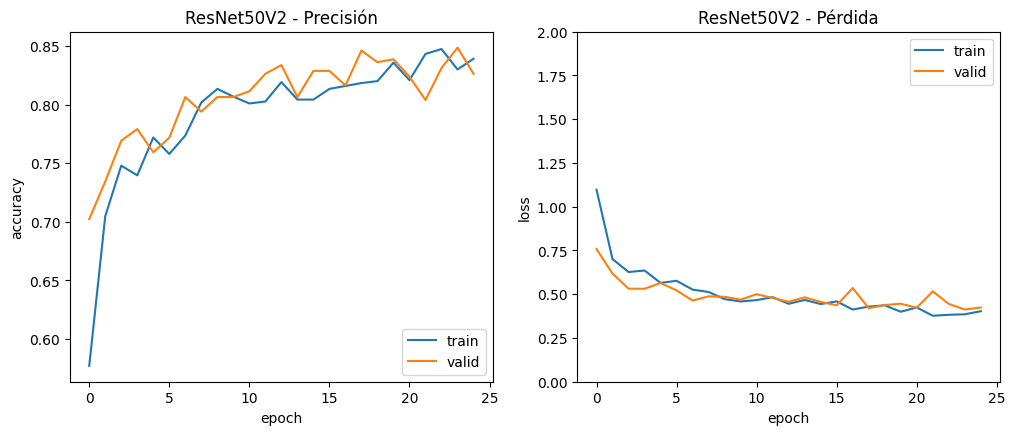

In [23]:
# Visualización del desempeño
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])
plt.title('ResNet50V2 - Precisión')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='lower right')

plt.subplot(2,2,2)
plt.plot(history_resnet.history['loss'])
plt.plot(history_resnet.history['val_loss'])
plt.title('ResNet50V2 - Pérdida')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='upper right')
plt.ylim([0, 2])
plt.show()

In [24]:
# ============================================
# MODELO DE TRANSFER LEARNING (PESADO)
# ============================================

#Modelo InceptionV3
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
# Número de clases (ajústalo según tu dataset)
num_classes = 3


In [25]:
# 1 Cargar el modelo base preentrenado (sin la parte superior)
base_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(75, 75, 3))

# 2 Congelar todas las capas (no se reentrenan)
base_inception.trainable = False

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
# 3 Construcción del clasificador superior
x = base_inception.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model_inception = Model(inputs=base_inception.input, outputs=output)


In [30]:
import tensorflow as tf

# Redimensionar las imágenes a 75x75
X_train_resized = tf.image.resize(X_train_scaled, (75, 75))
X_test_resized = tf.image.resize(X_test_scaled, (75, 75))

# Generadores con las nuevas dimensiones
train_generator = train_datagen.flow(X_train_resized, y_train, batch_size=32)
val_generator = test_datagen.flow(X_test_resized, y_test, batch_size=32)

In [31]:
# 4 Compilación del modelo
model_inception.compile(optimizer=Adam(learning_rate=1e-3),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

# 5 Entrenamiento del modelo (solo la parte superior)
history_inception = model_inception.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25
)

Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 39s 632ms/step - accuracy: 0.5489 - loss: 0.9826 - val_accuracy: 0.6873 - val_loss: 0.7116
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6575 - loss: 0.7561 - val_accuracy: 0.7171 - val_loss: 0.6549
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.7048 - loss: 0.6795 - val_accuracy: 0.7221 - val_loss: 0.6142
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7065 - loss: 0.6767 - val_accuracy: 0.7395 - val_loss: 0.6275
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.7206 - loss: 0.6315 - val_accuracy: 0.7717 - val_loss: 0.5707
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.7529 - loss: 0.5920 - val_accuracy: 0.7667 - val_loss: 0.5899
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.7479 - loss: 0.5874 - val_accuracy: 0.7618 - val_loss: 0.5775
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.7753 - loss: 0.5577 - val_accuracy: 0.7717 

Error del modelo InceptionV3 (sin fine-tuning): 19.35%


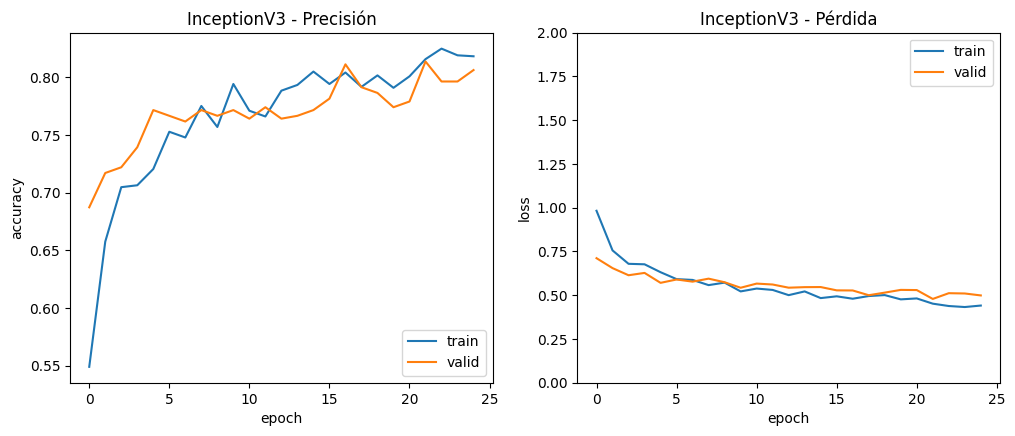

In [32]:
import tensorflow as tf

# Redimensionar las imágenes de prueba al tamaño de entrada del modelo
X_test_resized = tf.image.resize(X_test_scaled, (75, 75))

# Evaluación con el tamaño correcto
scores = model_inception.evaluate(X_test_resized, y_test, verbose=0)
print('Error del modelo InceptionV3 (sin fine-tuning): %.2f%%' % (100 - scores[1] * 100))

# 7 Guardado del modelo
model_inception.save('modelo_transfer_InceptionV3.keras')

# 8 Visualización del desempeño
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
plt.plot(history_inception.history['accuracy'])
plt.plot(history_inception.history['val_accuracy'])
plt.title('InceptionV3 - Precisión')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='lower right')

plt.subplot(2,2,2)
plt.plot(history_inception.history['loss'])
plt.plot(history_inception.history['val_loss'])
plt.title('InceptionV3 - Pérdida')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'valid'], loc='upper right')
plt.ylim([0, 2])
plt.show()